## Data Import

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.feature_extraction.text import CountVectorizer
import spacy
from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np
from scipy.stats import pearsonr
import matplotlib as mpl 
import pickle

In [ ]:
df_unified_salary = pd.read_csv("Unified_Resume_Salary_Dataset_ori.csv")

In [23]:
df_unified_salary.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23064 entries, 0 to 23063
Data columns (total 4 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Aligned_Text          23064 non-null  object 
 1   Annual_Median_Salary  23064 non-null  float64
 2   Log_Salary            23064 non-null  float64
 3   OCC_CODE              23064 non-null  object 
dtypes: float64(2), object(2)
memory usage: 720.9+ KB


In [30]:
df_unified_salary.describe()

,Annual_Median_Salary,Log_Salary
count,23064.000000,23064.000000
mean,97708.638137,11.437640
std,30194.415704,0.333696
min,34580.000000,10.451031
25%,72910.000000,11.196981
50%,98090.000000,11.493641
75%,112590.000000,11.631508
max,171200.000000,12.050588


## Salary Synthesizer

In [ ]:
import pandas as pd
import numpy as np
import re
from sklearn.feature_extraction.text import CountVectorizer

# TEXT CLEANING
# Removes punctuation and standardizes tech terms so "c++" and "c#" don't break.
def preserve_tech_syntax(text):
    if not isinstance(text, str):
        return ""
    return ' '.join(
        re.sub(r'[^a-z0-9\+\#\.]', ' ', str(text).lower()).split()
    )

# LOAD ONTOLOGY
df_occ = pd.read_csv("Unified_Occupation_Dataset.csv")

# Apply the text cleaner to our master list of skills.
df_occ['Clean_Feature'] = df_occ['Feature_Name'].apply(preserve_tech_syntax)

# Create a deduplicated master dictionary for the machine learning model.
master_vocab = (
    df_occ['Clean_Feature']
    .dropna()
    .drop_duplicates()
    .sort_values()
    .tolist()
)

# Grab the official importance weights for each skill so we know what matters.
global_avg_weights = (
    df_occ.groupby('Clean_Feature')['Importance_Score']
    .mean()
    .to_dict()
)

# LOAD WAGE DATA
oews_df = pd.read_csv('all_data_M_2024.csv', low_memory=False)

oews_df['OCC_CODE'] = oews_df['OCC_CODE'].astype(str)
oews_df['A_PCT10'] = pd.to_numeric(oews_df['A_PCT10'], errors='coerce')
oews_df['A_PCT90'] = pd.to_numeric(oews_df['A_PCT90'], errors='coerce')
oews_df['A_MEDIAN'] = pd.to_numeric(oews_df['A_MEDIAN'], errors='coerce')

# Filter down to just the national averages (Area 99, Industry 0).
national_oews = oews_df[
    (oews_df['AREA'].astype(str) == '99') &
    (oews_df['NAICS'] == '0')
].drop_duplicates(subset=['OCC_CODE'], keep='first')

# Build a fast lookup dictionary to match job codes to their salary bands.
oews_map = national_oews.set_index('OCC_CODE')[['A_PCT10', 'A_PCT90', 'A_MEDIAN']].to_dict('index')

# LOAD RESUME DATA
df = df_unified_salary.copy()

# Clean all the raw text in every resume.
df['Aligned_Text'] = df['Aligned_Text'].apply(preserve_tech_syntax)

# Map the official salary boundaries to each individual resume based on its job code.
df['A_PCT10'] = df['OCC_CODE'].apply(lambda x: oews_map.get(str(x), {}).get('A_PCT10', np.nan))
df['A_PCT90'] = df['OCC_CODE'].apply(lambda x: oews_map.get(str(x), {}).get('A_PCT90', np.nan))
df['A_MEDIAN'] = df['OCC_CODE'].apply(lambda x: oews_map.get(str(x), {}).get('A_MEDIAN', np.nan))

# If a job code is missing, calculate emergency fallback values from the dataset.
q10 = df['Annual_Median_Salary'].quantile(0.1)
q90 = df['Annual_Median_Salary'].quantile(0.9)
q50 = df['Annual_Median_Salary'].median()

# Plug the holes so there are no empty salary values.
df['A_PCT10'] = df['A_PCT10'].fillna(q10)
df['A_PCT90'] = df['A_PCT90'].fillna(q90)
df['A_MEDIAN'] = df['A_MEDIAN'].fillna(q50)

# VECTORIZATION
# Setup the scanner to hunt for exactly the words in our master vocabulary.
vectorizer = CountVectorizer(
    vocabulary=master_vocab,
    ngram_range=(1, 3),
    token_pattern=r'(?u)\.?[a-z0-9][a-z0-9\+\#\.]*',
    binary=True
)

# Convert all text into a massive grid of 1s and 0s (True/False for each skill).
X = vectorizer.transform(df['Aligned_Text']).toarray()
X = (X > 0).astype(float)

# SKILL SCORING (STABLE + NON-EXPLOSIVE)
# Explanation: Calculates a raw skill score for each resume by combining the rarity 
# of the word (TF-IDF) with its official O*NET importance weight, then applies a soft 
# log compression to prevent keyword stuffers from breaking the math.

N = len(df)
doc_freq = np.sum(X, axis=0)

# Calculate TF-IDF to punish super common buzzwords (like "teamwork") and reward rare skills.
idf = np.log((1 + N) / (1 + doc_freq)) + 1

# Align the official O*NET importance weights with our vocabulary array.
ontology_weights = np.array([
    global_avg_weights.get(w, 1.0) for w in master_vocab
])

# Multiply the rarity of the word by its official importance.
weights = ontology_weights * idf

# Calculate the raw point total for every single resume.
raw_score = np.dot(X, weights)

# Compress the scores gently so people who stuffed their resume don't break the math.
skill_score = np.log1p(raw_score)

df['Skill_Score'] = skill_score

# OCCUPATION CONTEXT NORMALIZATION 
# Explanation: Calculates a localized Z-score to determine how a candidate compares 
# exclusively to other people in their exact same job, rather than the entire dataset.

# Find the average skill score specifically for each job title.
occ_mean = df.groupby('OCC_CODE')['Skill_Score'].transform('mean')
occ_std = df.groupby('OCC_CODE')['Skill_Score'].transform('std')

# Calculate how far above or below average this specific candidate is compared to peers.
z = (df['Skill_Score'] - occ_mean) / (occ_std + 1e-6)
# Cap the outliers so a massive score doesn't ruin the curve.
z = np.clip(z, -3.5, 3.5)

# Squeeze the z-score into a smooth 0-to-1 ranking fraction.
skill_signal = 1 / (1 + np.exp(-z))  

# OCCUPATION PRIOR 
# Explanation: Normalizes the base median salary of the specific occupation into 
# a 0-to-1 scale to ensure inherently high-paying jobs retain their natural market advantage.

occ_prior = df['A_MEDIAN'].values

# Normalize the base job salary into a 0-to-1 multiplier.
occ_prior_norm = (occ_prior - np.min(occ_prior)) / (np.max(occ_prior) - np.min(occ_prior) + 1e-6)

# HYBRID SALARY SIGNAL 
# Explanation: Blends the candidate's personal skill rank with their occupation's 
# base market value to create a unified 0-to-1 performance multiplier.

alpha = 0.9

# Combine the skill ranking and the job baseline.
final_signal = (
    alpha * skill_signal +         # 90% weight on skill
    (1 - alpha) * occ_prior_norm   # 10% weight on occupation median salary
)

# RIGHT-SKEW TRANSFORMATION (THE GAMMA LEVER)
# Explanation: Applies an exponential curve to push the majority of salaries downward,
# replicating the realistic "long tail" income distribution where only a few earn top dollar.

# By raising the fraction to a power > 1, we push most salaries down, creating a realistic upper-class skew.
gamma = 1.6  

skewed_signal = final_signal ** gamma

# RESCALE WITH SOFT MACRO SPREAD
# Maps the 0-to-1 signal back into actual dollars by sliding it between a blended 
# floor and ceiling that accounts for both the specific job and the broader global economy.

# Find the absolute poorest and richest boundaries in the entire dataset.
global_floor = df['A_PCT10'].min()
global_ceiling = df['A_PCT90'].max()

macro_gravity = 0.40

# Blend the specific job's salary limits with the global economy limits.
blended_floor = ((1 - macro_gravity) * df['A_PCT10'].values) + (macro_gravity * global_floor)
blended_ceiling = ((1 - macro_gravity) * df['A_PCT90'].values) + (macro_gravity * global_ceiling)
blended_spread = blended_ceiling - blended_floor

# Finally, map the 0-1 ranking onto the actual dollar spread.
salary = blended_floor + (skewed_signal * blended_spread)

# GLOBAL CALIBRATION
# Explanation: Anchors the entire dataset to the national median wage and applies 
# a 30% discount to accurately simulate a younger, entry-level student demographic.

national_oews['A_MEDIAN'] = pd.to_numeric(national_oews['A_MEDIAN'], errors='coerce')

target_median = np.nanmedian(national_oews['A_MEDIAN'])

# Apply a 30% discount to all wages to simulate a younger/entry-level student demographic.
market_discount = 0.7  
 
calibrated_target = target_median * market_discount

# Force the entire dataset down to anchor to the new discounted median.
salary = salary * (calibrated_target / np.median(salary))

# SMALL REALISM NOISE
# Inject a random variance (0.1%) so no two identical resumes have exactly the same penny.
np.random.seed(42)
salary *= np.random.normal(1.0, 0.001, len(df))


# FINAL OUTPUT
df['Annual_Median_Salary_Syn'] = np.round(salary, 2)
df['Log_Salary'] = np.log1p(df['Annual_Median_Salary_Syn'])

print("Salary Synthetization complete")

Salary Synthetization complete


In [33]:
# Select final columns
df_unified_salary_final = df[['Aligned_Text','Annual_Median_Salary_Syn', 'Log_Salary', 'OCC_CODE']]

# Save final dataset
df_unified_salary_final.to_csv('Unified_Resume_Salary_Dataset.csv', index=False)


## Data Understanding

In [5]:
print("Dataset shape:", df_unified_salary_final.shape)
print(df_unified_salary_final.head())
print(df_unified_salary_final.info())
print(df_unified_salary_final.describe())

Dataset shape: (23064, 4)
                                        Aligned_Text  \
0  administration and management administrative e...   
1  administration and management adobe after effe...   
2  administration and management administrative c...   
3  administration and management biology communic...   
4  administration and management communications a...   

   Annual_Median_Salary_Syn  Log_Salary OCC_CODE  
0                  45261.13   10.720226  11-2021  
1                  56491.06   10.941855  11-2021  
2                  34480.12   10.448167  11-2021  
3                  39985.69   10.596302  11-2021  
4                  38199.98   10.550616  11-2021  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23064 entries, 0 to 23063
Data columns (total 4 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Aligned_Text              23064 non-null  object 
 1   Annual_Median_Salary_Syn  23064 non-null  float64
 2 

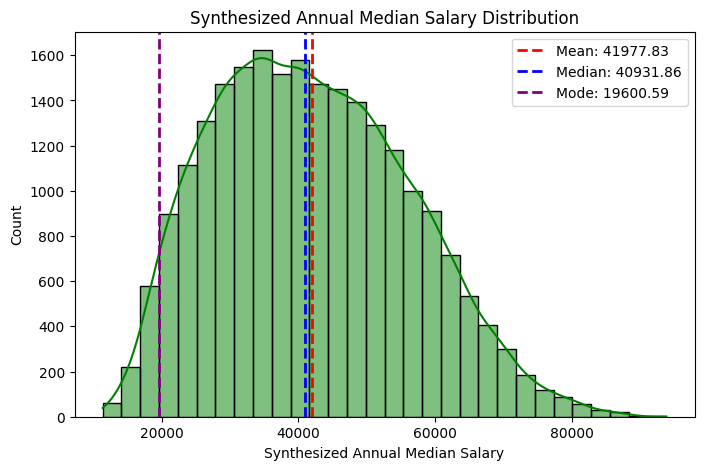

In [6]:
mean_val = df_unified_salary_final['Annual_Median_Salary_Syn'].mean()
median_val = df_unified_salary_final['Annual_Median_Salary_Syn'].median()
mode_val = df_unified_salary_final['Annual_Median_Salary_Syn'].mode().iloc[0]   

plt.figure(figsize=(8,5))

sns.histplot(df_unified_salary_final['Annual_Median_Salary_Syn'], bins=30, kde=True, color='green')

# Mean
plt.axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f"Mean: {mean_val:.2f}")

# Median
plt.axvline(median_val, color='blue', linestyle='--', linewidth=2, label=f"Median: {median_val:.2f}")

# Mode
plt.axvline(mode_val, color='purple', linestyle='--', linewidth=2, label=f"Mode: {mode_val:.2f}")

plt.title("Synthesized Annual Median Salary Distribution")
plt.xlabel("Synthesized Annual Median Salary")
plt.ylabel("Count")
plt.legend()
plt.show()

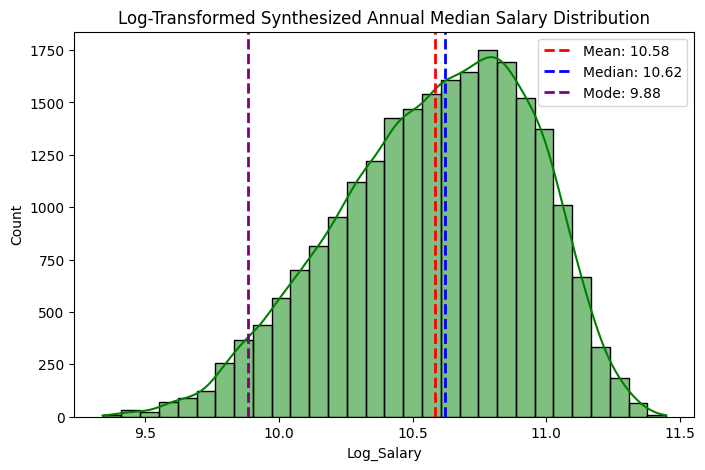

In [8]:
mean_val = df_unified_salary_final['Log_Salary'].mean()
median_val = df_unified_salary_final['Log_Salary'].median()
mode_val = df_unified_salary_final['Log_Salary'].mode().iloc[0]   

plt.figure(figsize=(8,5))

sns.histplot(df_unified_salary_final['Log_Salary'], bins=30, kde=True, color='green')

# Mean
plt.axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f"Mean: {mean_val:.2f}")

# Median
plt.axvline(median_val, color='blue', linestyle='--', linewidth=2, label=f"Median: {median_val:.2f}")

# Mode
plt.axvline(mode_val, color='purple', linestyle='--', linewidth=2, label=f"Mode: {mode_val:.2f}")

plt.title("Log-Transformed Synthesized Annual Median Salary Distribution")
plt.xlabel("Log_Salary")
plt.ylabel("Count")
plt.legend()
plt.show()

C:\Users\cjc72\AppData\Local\Temp\ipykernel_27420\1143355322.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


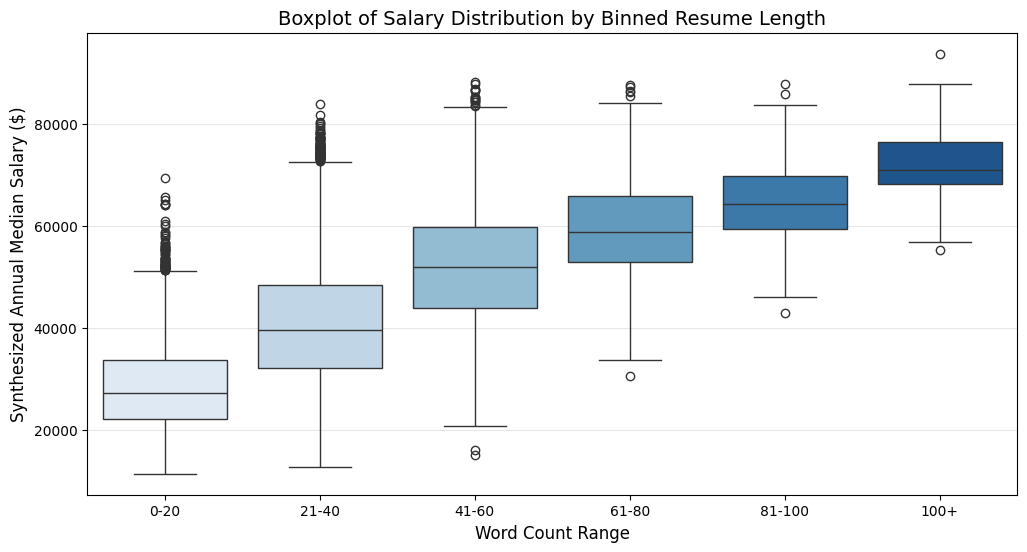

In [10]:
# 1. Create specific bins based on data distribution
bins = [0, 20, 40, 60, 80, 100, np.inf]
labels = ['0-20', '21-40', '41-60', '61-80', '81-100', '100+']

df_unified_salary_final['Word_Count'] = df_unified_salary_final['Aligned_Text'].apply(lambda x: len(str(x).split()))

df_unified_salary_final['Word_Count_Bin'] = pd.cut(
    df_unified_salary_final['Word_Count'], 
    bins=bins, 
    labels=labels
)

# 2. OPTION A: Box Plot (Best for distribution & outliers)
plt.figure(figsize=(12, 6))
sns.boxplot(
    data=df_unified_salary_final, 
    x='Word_Count_Bin', 
    y='Annual_Median_Salary_Syn',
    palette="Blues"
)
plt.title('Boxplot of Salary Distribution by Binned Resume Length', fontsize=14)
plt.xlabel('Word Count Range', fontsize=12)
plt.ylabel('Synthesized Annual Median Salary ($)', fontsize=12)
plt.grid(axis='y', alpha=0.3)
plt.show()

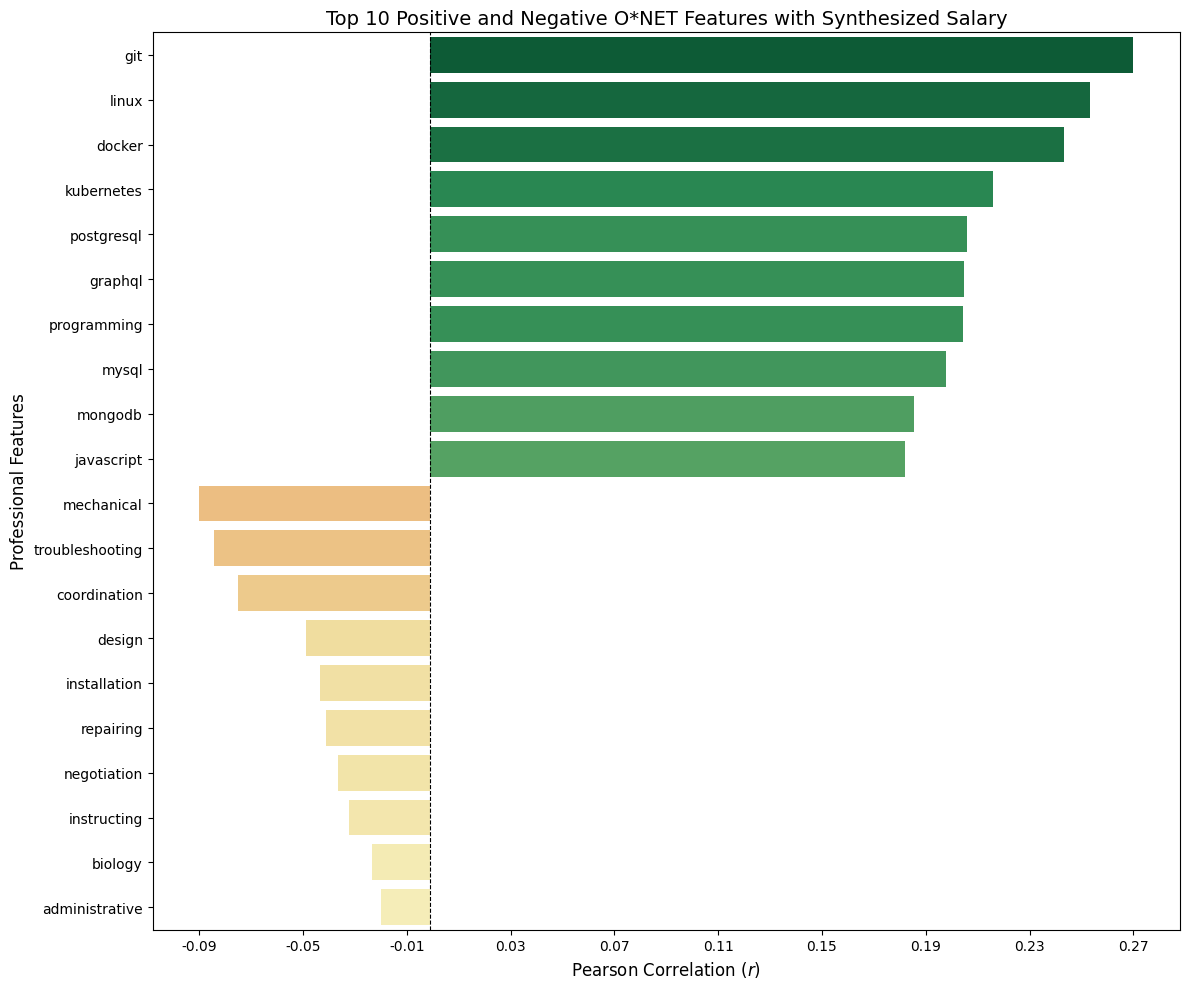

In [13]:
# 1. SETUP & DATA LOADING
# Assuming df_unified_salary_final is defined
texts = df_unified_salary_final['Aligned_Text'].astype(str)
salary = df_unified_salary_final['Annual_Median_Salary_Syn'].values

with open('master_vocab.pkl', 'rb') as f:
    master_vocab = pickle.load(f)

# 2. TF-IDF VECTORIZATION
vectorizer = TfidfVectorizer(
    vocabulary=master_vocab,
    token_pattern=r'(?u)\.?[a-z0-9][a-z0-9\+\#\.]*' 
)

X = vectorizer.fit_transform(texts)
feature_names = np.array(vectorizer.get_feature_names_out())

# 3. CORRELATION ANALYSIS
correlations = []
for i in range(X.shape[1]):
    word_scores = X[:, i].toarray().ravel()
    if np.std(word_scores) == 0:
        correlations.append((feature_names[i], 0.0, 1.0))
        continue
    corr, p = pearsonr(word_scores, salary)
    correlations.append((feature_names[i], corr, p))

corr_df = pd.DataFrame(correlations, columns=['Features', 'Correlation', 'P_Value'])
significant_corr = corr_df[corr_df['P_Value'] < 0.05]

top_pos = significant_corr.sort_values('Correlation', ascending=False).head(10)
top_neg = significant_corr.sort_values('Correlation', ascending=True).head(10)
plot_df = pd.concat([top_pos, top_neg])

# 4. GRADIENT PLOTTING (FIXED WARNINGS)
plt.figure(figsize=(12, 10))

# FIX 1: Use matplotlib.colormaps directly instead of deprecated get_cmap
v_abs_max = max(abs(plot_df['Correlation'].min()), abs(plot_df['Correlation'].max()))
norm = plt.Normalize(vmin=-v_abs_max, vmax=v_abs_max)
cmap = mpl.colormaps['RdYlGn'] 
colors = [cmap(norm(x)) for x in plot_df['Correlation']]

# FIX 2: Assign 'Features' to hue and set legend=False to avoid FutureWarning
sns.barplot(
    x='Correlation',
    y='Features',
    data=plot_df,
    hue='Features', 
    palette=colors,
    legend=False
)

plt.title('Top 10 Positive and Negative O*NET Features with Synthesized Salary', fontsize=14)
plt.xlabel('Pearson Correlation ($r$)', fontsize=12)
plt.ylabel('Professional Features', fontsize=12)
plt.axvline(0, color='black', linewidth=0.8, linestyle='--')

min_val, max_val = plot_df['Correlation'].min(), plot_df['Correlation'].max()
plt.xticks(
    ticks=np.linspace(min_val, max_val, num=10),
    labels=[f"{x:.2f}" for x in np.linspace(min_val, max_val, num=10)]
)

plt.tight_layout()
plt.show()